## Dan's Notes: Supplemental Materials for Learning Tree Course 1267
### Discrete Fourier Transform
<br/>
<br/>

©2019-2025 Daniel R. Buskirk<br/>
dan@ai1729.com<br/>

In [1]:
using Plots
using FFTW

There is nothing about the discrete Fourier transform that requires a number of data points that is an even power of 2. However, a popular FFT algorithm repeately divides the data in half, so a power of two is convenient. There are other algoritms, such as Bluestein’s FFT and Rader’s FFT, which use different algorithms.


In [2]:
# Number of points
N = 16384
# Sample spacing
Ts = 10 / (1.1 * N)
# Sample rate
fs = 1 / Ts
# Start time
t0 = 0
tmax = t0 + N * Ts

# time coordinate
t = t0:Ts:tmax

0.0:0.0005548650568181818:9.09090909090909

Our synthetic data consists of three frequencie, one at 2 times the fundamental and one at three. After the synthetic signal is created, noise is added. This will be the starting point for our analysis.<br/>
From a standpoint of convenience and readability it is nice that Julia lets us specify periods as 2π, 4π and 6π.

In [4]:
# signal = sin.(2π * 60 * t) + .5 * sin.(2π * 120 * t)
signal = 0.5 * cos.(2π .* t) + 1.5 * cos.(4π .* t .+ π/3) + 0.75 * cos.(6π .* t)
noise = randn(size(t))
original_signal = signal + noise;

In [7]:
pwd()

"A:\\Knowledgebase\\Julia\\JuliaNotebooks\\FourierStuff"

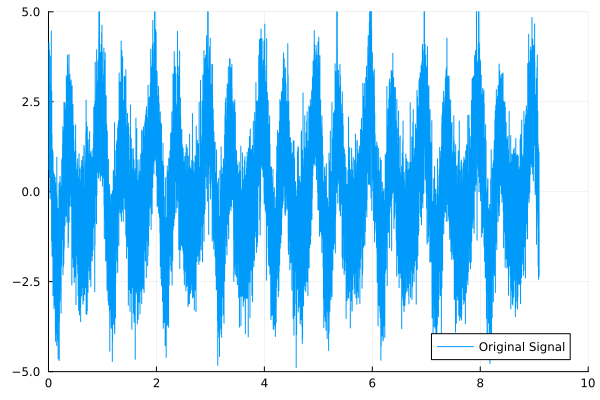

"A:\\Knowledgebase\\Julia\\JuliaNotebooks\\FourierStuff\\OriginalDataWithNoise.png"

In [8]:
# The `fft` function calculates the (discrete) Fourier transform of its input.
# The first half of the returned array contains the positive frequencies, while
# the second half contains the negative ones. For visualization purposes, we
# rearrange the array to have the zero-frequency at the center.


FFT = fft(original_signal)
# shifted_FFT=  fftshift(fft(original_signal))
shifted_FFT = fftshift(FFT)

freqs =  fftshift(fftfreq(length(t), fs))

# Plot
# time_domain = plot(t, signal, title="Signal", xlims=(0, 4 / 60), xlabel="time (s)", label="")
# time_domain = plot(t, original_signal, title="Signal", xlims=(0, 10 ), xlabel="time (s)", label="")
# freq_domain = plot(freqs, abs.(F), title="Spectrum", xlims=(0, 200), xlabel="frequency (Hz)", label="")
# plot(time_domain, freq_domain, layout = 2)
# plot(time_domain);
figOriginal = plot(t, original_signal, label="Original Signal", xlims=(0,10), ylims=(-5,5));

# figFiltered = plot(t, filtered_signal, label="Filtered Signal");
display(figOriginal)
# display(figFiltered)

savefig("OriginalDataWithNoise.png")

To keep the sample code as simple as practical, the raw FFT output is not normalized, meaning the magnitude depends on the number of samples (N). This would be undesireable when analyzing real data, but here it does not affect our appreciation of the basic steps.


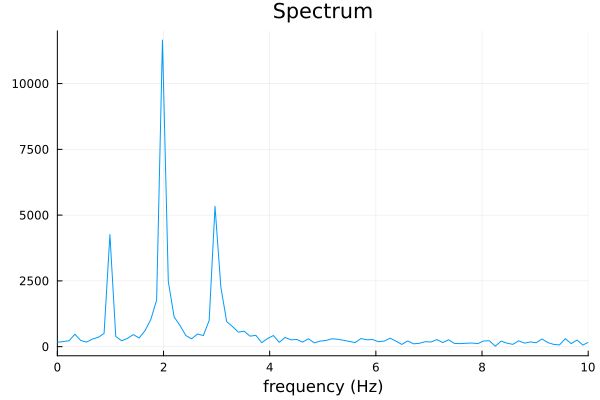

In [9]:
freq_domain = plot(freqs, abs.(shifted_FFT), title="Spectrum", xlims=(0, 10), xlabel="frequency (Hz)", label="")
display(freq_domain)

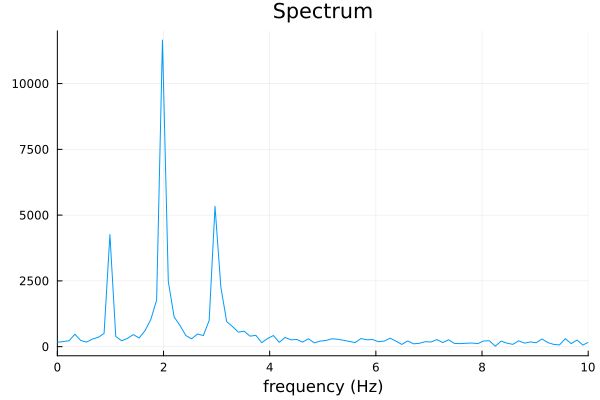

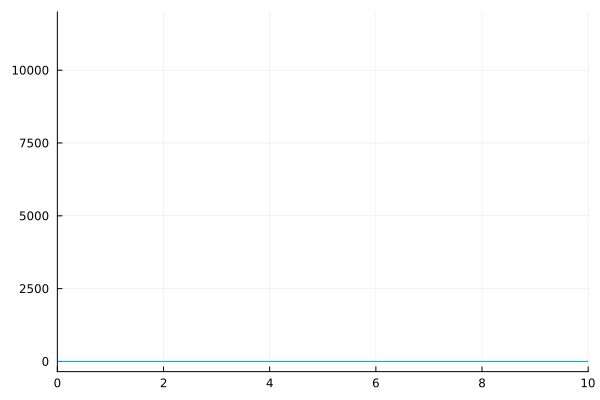

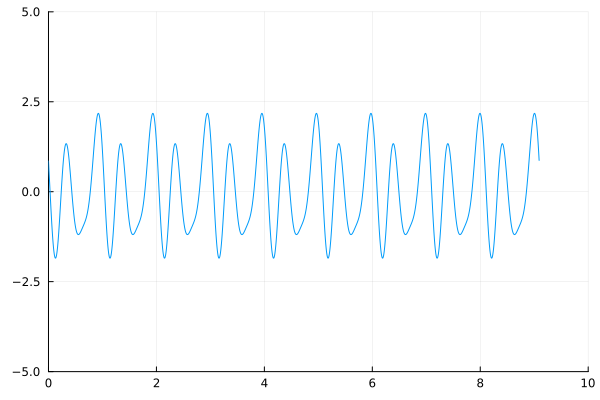

In [11]:
# Set a threshold to filter out low-amplitude frequencies (adjust as needed)
threshold = 2500.0

freq_domain = plot(freqs, abs.(shifted_FFT), title="Spectrum", xlims=(0, 10), xlabel="frequency (Hz)", label="", legend=false)
savefig("SpectrumOfOriginalDataWithNoise.png")
display(freq_domain)

# display(plot(F .* real((abs.(F)))))

F_filtered =  FFT .*  (abs.(FFT) .> threshold)   # Zero out low-amplitude components

display(plot(freqs, abs.(F_filtered), xlims=(0, 10), legend=false))

# Compute the inverse FFT to get the filtered signal
filtered_signal = real(ifft(F_filtered));
figFiltered = plot(t, filtered_signal, label="Original Signal", xlims=(0,10), ylims=(-5,5), legend=false);
savefig("FilteredData.png")
display(figFiltered)
